### Spectral Clustering Via Eigenvalue Decomposition

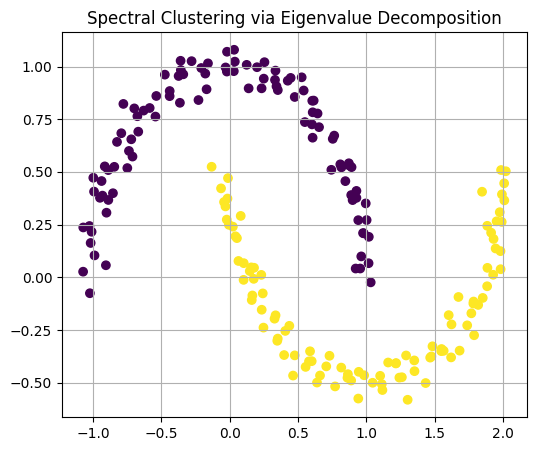

In [42]:
from sklearn.datasets import make_moons
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create non-linearly separable data
X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

# Step 2: Compute the similarity matrix using RBF kernel
gamma = 15
S = rbf_kernel(X, gamma=gamma)

# Step 3: Compute the Degree and Laplacian matrices
D = np.diag(S.sum(axis=1))
L = D - S  # Unnormalized Laplacian

# Step 4: Compute the first k eigenvectors of the Laplacian
eigenvalues, eigenvectors = np.linalg.eigh(L)
k = 2  # Number of clusters
X_spec = eigenvectors[:, :k]  # Use smallest k eigenvectors

# Step 5: Normalize rows (optional but recommended for spectral clustering)
X_spec_norm = X_spec / np.linalg.norm(X_spec, axis=1, keepdims=True)

# Step 6: Cluster using k-means
labels = KMeans(n_clusters=2, random_state=0).fit_predict(X_spec_norm)

# Plot result
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("Spectral Clustering via Eigenvalue Decomposition")
plt.grid(True)
plt.show()


### Spectral Clustering Example using SpectralClustering from Sklearn

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.cluster import SpectralClustering 
from sklearn.preprocessing import StandardScaler, normalize 
from sklearn.decomposition import PCA 
from sklearn.metrics import silhouette_score 

In [7]:
raw_df = pd.read_csv("CC GENERAL.csv")
raw_df = raw_df.drop('CUST_ID', axis = 1) 
raw_df.fillna(method ='ffill', inplace = True) 
raw_df.head(2)

/var/folders/68/hjr0dmf11mdcgw23xxzbtqzc0000gn/T/ipykernel_8391/2200629991.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  raw_df.fillna(method ='ffill', inplace = True)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.4,0.0,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.0,0.0,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12


In [17]:
# Preprocessing the data to make it visualizable 
  
# Scaling the Data 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(raw_df) 
  
# Normalizing the Data 
X_normalized = normalize(X_scaled) 
  
# Converting the numpy array into a pandas DataFrame 
X_normalized = pd.DataFrame(X_normalized) 
  
# Reducing the dimensions of the data 
pca = PCA(n_components = 2) 
X_principal = pca.fit_transform(X_normalized) 
X_principal = pd.DataFrame(X_principal) 
X_principal.columns = ['P1', 'P2'] 
  
X_principal.head(2) 

,P1,P2
0,-0.489949,-0.679976
1,-0.519099,0.544827


In [18]:
# Building the clustering model 
spectral_model_rbf = SpectralClustering(n_clusters = 2, affinity ='rbf') 
  
# Training the model and Storing the predicted cluster labels 
labels_rbf = spectral_model_rbf.fit_predict(X_principal)

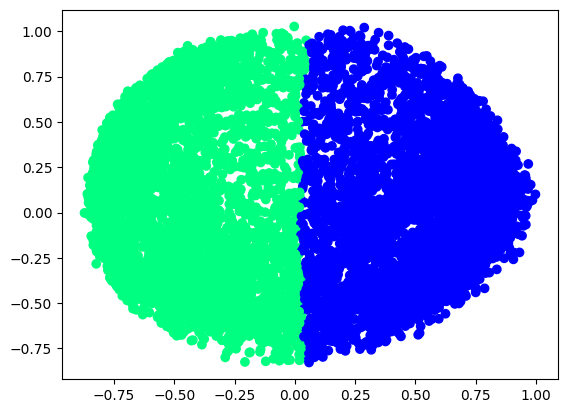

In [19]:
# Visualizing the clustering 
plt.scatter(X_principal['P1'], X_principal['P2'],
           c = SpectralClustering(n_clusters = 2, affinity ='rbf') .fit_predict(X_principal), cmap =plt.cm.winter) 
plt.show()

### Spectral Clustering from scratch

In [ ]:
pip install numpy scipy matplotlib scikit-learn

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import eigh


In [24]:
# STEP 1: Create sample data
X, _ = make_moons(n_samples=200, noise=0.05)

In [28]:
# STEP 2: Build Similarity Matrix using RBF Kernel
def rbf_kernel(X, sigma=0.1):
    pairwise_sq_dists = squareform(pdist(X, 'sqeuclidean'))
    W = np.exp(-pairwise_sq_dists / (2 * sigma ** 2))
    return W
W = rbf_kernel(X, sigma=0.2)

In [29]:
# STEP 3: Degree matrix
D = np.diag(np.sum(W, axis=1))

In [30]:
# STEP 4: Laplacian matrix (unnormalized)
L = D - W

In [33]:
# STEP 5: Compute first k eigenvectors (smallest eigenvalues)
k = 2
eigvals, eigvecs = eigh(L, subset_by_index=[0, k-1])  # smallest k

In [34]:
# STEP 6: Use eigenvectors as new features
U = eigvecs

In [35]:
# STEP 7: Apply k-means to rows of U
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(U)

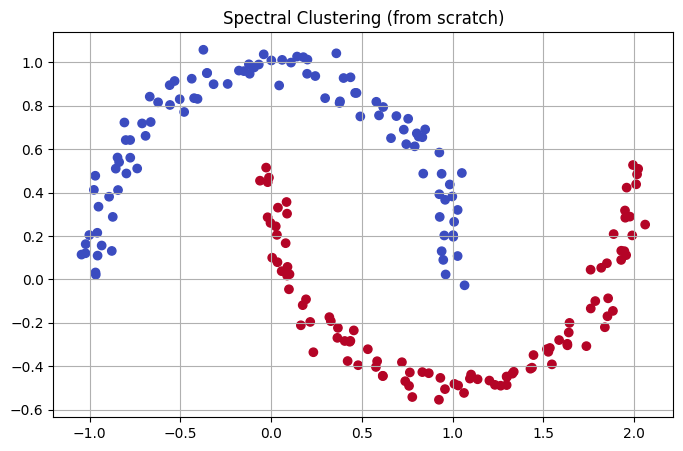

In [36]:
# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm')
plt.title("Spectral Clustering (from scratch)")
plt.grid(True)
plt.show()

### Spectral Clustering in Graph

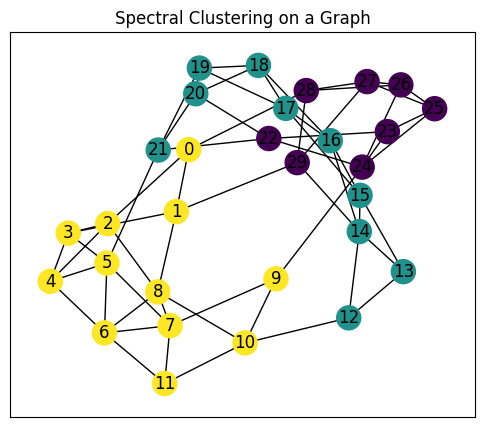

In [43]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering

# Step 1: Create a synthetic graph
G = nx.connected_watts_strogatz_graph(n=30, k=4, p=0.1, seed=42)

# Step 2: Get adjacency matrix
A = nx.to_numpy_array(G)

# Step 3: Spectral clustering
n_clusters = 3
sc = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', assign_labels='kmeans')
labels = sc.fit_predict(A)

# Step 4: Visualize the clustered graph
plt.figure(figsize=(6, 5))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(G, pos=pos, node_color=labels, cmap='viridis', with_labels=True)
plt.title("Spectral Clustering on a Graph")
plt.show()
